# H.S DIESEL Monthly Consumption Model

Predicts monthly diesel consumption for the sugar mill using a simple regime-median model (crushing season Oct–Apr vs off-season May–Sep).

In [1]:
# Section 1 – Load data
# Read the raw transaction log, filter to H.S DIESEL (LTR), deduplicate
# identical rows, aggregate to monthly totals, and fill missing months with 0.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from IPython.display import display
import joblib
import sys
sys.path.append(".")
from src.data import get_monthly_series

RAW_FILE   = "consumption_data.xlsx"
ITEM       = "H.S DIESEL"
UOM        = "LTR"
TRAIN_END  = "2024-12-01"   # last training month
TEST_START = "2025-01-01"   # first test month

df_raw = pd.read_excel(RAW_FILE)
df_ts, _ = get_monthly_series(df_raw, ITEM, UOM, dedupe=True)

df_ts["Month"]              = df_ts["Month_Start"].dt.month
df_ts["Year"]               = df_ts["Month_Start"].dt.year
df_ts["is_crushing_season"] = df_ts["Month"].apply(lambda m: 1 if m >= 10 or m <= 4 else 0)

print(f"Rows: {len(df_ts)} months  |  "
      f"{df_ts['Month_Start'].min().strftime('%b %Y')} – "
      f"{df_ts['Month_Start'].max().strftime('%b %Y')}")
print(f"Total consumption: {df_ts['Consumption_Qty'].sum():,.0f} LTR")
df_ts.head()


Rows: 55 months  |  Jun 2021 – Dec 2025
Total consumption: 120,974 LTR


,Month_Start,Consumption_Qty,Month,Year,is_crushing_season
0,2021-06-01,5870.0,6,2021,0
1,2021-07-01,4631.0,7,2021,0
2,2021-08-01,1798.5,8,2021,0
3,2021-09-01,175.0,9,2021,0
4,2021-10-01,2144.0,10,2021,1


## 2. Monthly Consumption (Crushing Season Shaded)

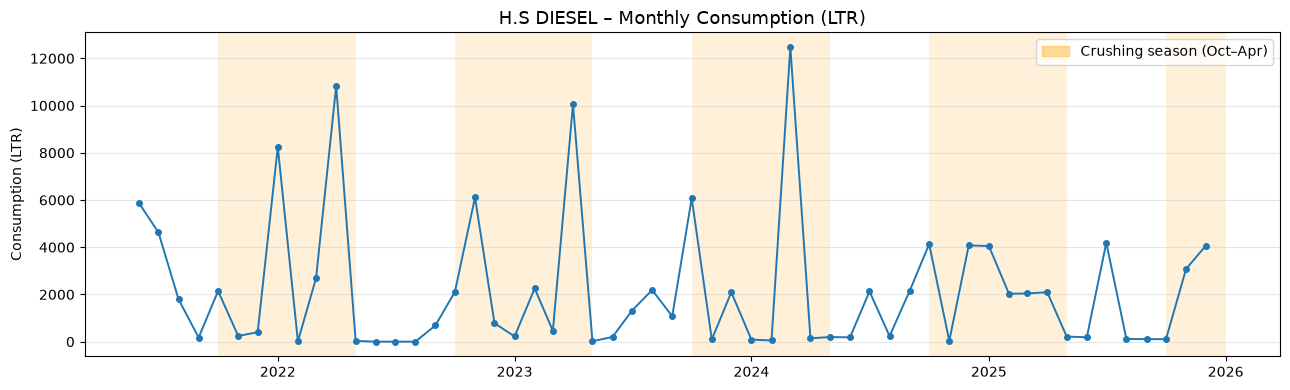

In [2]:
# Section 2 – Time-series plot with crushing season (Oct–Apr) shaded orange.

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(df_ts["Month_Start"], df_ts["Consumption_Qty"],
        marker="o", markersize=4, linewidth=1.4, color="#1f77b4")

for _, row in df_ts[df_ts["is_crushing_season"] == 1].iterrows():
    ax.axvspan(row["Month_Start"],
               row["Month_Start"] + pd.DateOffset(months=1),
               alpha=0.15, color="orange", linewidth=0)

ax.set_title("H.S DIESEL – Monthly Consumption (LTR)", fontsize=13)
ax.set_ylabel("Consumption (LTR)")
ax.set_xlabel("")
ax.grid(axis="y", alpha=0.3)
orange_patch = mpatches.Patch(color="orange", alpha=0.4, label="Crushing season (Oct–Apr)")
ax.legend(handles=[orange_patch], loc="upper right")
plt.tight_layout()
plt.show()


## 3. Model – Regime Median

In [3]:
# Section 3 – Fit the model on all data up to Dec 2025.
# For each regime predict the historical median monthly consumption.
# Also record means and 10th/90th percentiles for uncertainty and totals.

train = df_ts.copy()   # all 54 months (Jun 2021 – Dec 2025)

model = {
    "medians": train.groupby("is_crushing_season")["Consumption_Qty"].median(),
    "means":   train.groupby("is_crushing_season")["Consumption_Qty"].mean(),
    "p10":     train.groupby("is_crushing_season")["Consumption_Qty"].quantile(0.10),
    "p90":     train.groupby("is_crushing_season")["Consumption_Qty"].quantile(0.90),
}

params = pd.DataFrame({
    "Median (LTR)": model["medians"],
    "Mean (LTR)":   model["means"],
    "10th pct":     model["p10"],
    "90th pct":     model["p90"],
})
params.index = ["Off-season (May–Sep)", "Crushing (Oct–Apr)"]
print("Model parameters:")
display(params.round(1))


Model parameters:


,Median (LTR),Mean (LTR),10th pct,90th pct
Off-season (May–Sep),207.5,1154.1,5.3,3587.4
Crushing (Oct–Apr),2095.0,3008.9,86.5,8245.0


## 4. Evaluation on 2025 Actuals

In [4]:
# Section 4 – Evaluate on the 2025 test year (real, uncapped actuals).
# Train on Jun 2021 – Dec 2024; test on Jan – Dec 2025.
# Compare regime-median to the naive "same month last year" baseline.

train_eval = df_ts[df_ts["Month_Start"] <= TRAIN_END].copy()
test_eval  = df_ts[df_ts["Month_Start"] >= TEST_START].copy()

medians_eval = train_eval.groupby("is_crushing_season")["Consumption_Qty"].median()

# Regime-median predictions
test_eval = test_eval.copy()
test_eval["pred_regime"] = test_eval["is_crushing_season"].map(medians_eval)

# Naive: same month last year (lag-12)
lag_map = (train_eval.set_index("Month_Start")["Consumption_Qty"]
           .rename_axis("Month_Start"))
test_eval["pred_naive"] = test_eval["Month_Start"].apply(
    lambda d: lag_map.get(d - pd.DateOffset(years=1), np.nan))

def mae(y, yhat): return np.mean(np.abs(y - yhat))
def wape(y, yhat): return np.sum(np.abs(y - yhat)) / np.sum(y)

actuals = test_eval["Consumption_Qty"].values
results = pd.DataFrame({
    "Model":   ["Regime Median", "Naive (last year)"],
    "MAE":     [mae(actuals, test_eval["pred_regime"]),
                mae(actuals, test_eval["pred_naive"].fillna(0))],
    "WAPE":    [f"{wape(actuals, test_eval['pred_regime']):.1%}",
                f"{wape(actuals, test_eval['pred_naive'].fillna(0)):.1%}"],
})
print("2025 test results:")
display(results)


2025 test results:


,Model,MAE,WAPE
0,Regime Median,941.041667,50.7%
1,Naive (last year),2473.583333,133.3%


## 5. Forecast Jan–Dec 2026

,Month_Start,Season,Forecast (LTR),Lower 10th (LTR),Upper 90th (LTR)
0,Jan 2026,Crushing (Oct–Apr),2095.0,86.50,8245.0
1,Feb 2026,Crushing (Oct–Apr),2095.0,86.50,8245.0
2,Mar 2026,Crushing (Oct–Apr),2095.0,86.50,8245.0
3,Apr 2026,Crushing (Oct–Apr),2095.0,86.50,8245.0
4,May 2026,Off-season (May–Sep),207.5,5.25,3587.4
5,Jun 2026,Off-season (May–Sep),207.5,5.25,3587.4
6,Jul 2026,Off-season (May–Sep),207.5,5.25,3587.4
7,Aug 2026,Off-season (May–Sep),207.5,5.25,3587.4
8,Sep 2026,Off-season (May–Sep),207.5,5.25,3587.4
9,Oct 2026,Crushing (Oct–Apr),2095.0,86.50,8245.0



Season totals (regime mean × months):


,Period,Months,Expected Total (LTR)
0,Jan–Apr 2026 (Crushing),4,12036
1,May–Sep 2026 (Off-season),5,5770
2,Oct–Dec 2026 (Crushing),3,9027
3,TOTAL 2026,12,26833


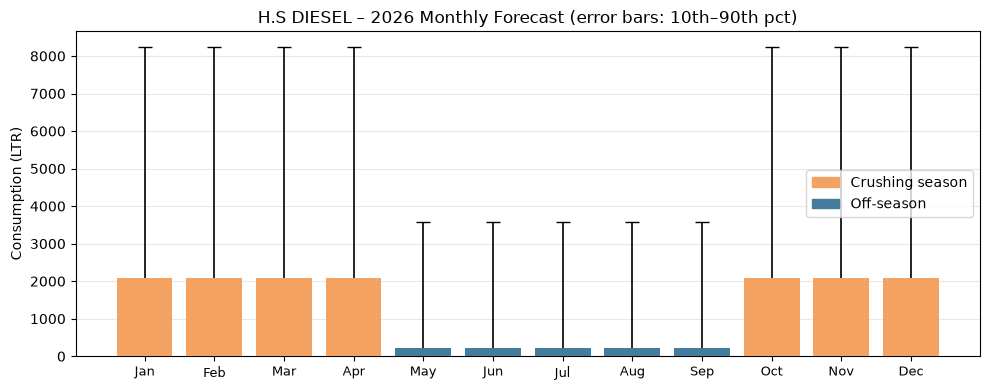


Saved: models/regime_median.joblib  |  forecast_2026.csv


In [5]:
# Section 5 – Point forecast = regime median.
# Uncertainty band = empirical 10th–90th percentile from all training months.
# Season totals use the regime MEAN × number of months (medians undercount
# because they ignore the high-consumption outlier months that do occur).

import os

f_dates = pd.date_range(start="2026-01-01", end="2026-12-01", freq="MS")
fcast = pd.DataFrame({"Month_Start": f_dates})
fcast["Month"]              = fcast["Month_Start"].dt.month
fcast["Season"]             = fcast["Month"].apply(
    lambda m: "Crushing (Oct–Apr)" if m >= 10 or m <= 4 else "Off-season (May–Sep)")
fcast["is_crushing_season"] = fcast["Month"].apply(lambda m: 1 if m >= 10 or m <= 4 else 0)

fcast["Forecast (LTR)"]   = fcast["is_crushing_season"].map(model["medians"])
fcast["Lower 10th (LTR)"] = fcast["is_crushing_season"].map(model["p10"])
fcast["Upper 90th (LTR)"] = fcast["is_crushing_season"].map(model["p90"])

display(fcast[["Month_Start", "Season", "Forecast (LTR)", "Lower 10th (LTR)", "Upper 90th (LTR)"]].
        assign(Month_Start=lambda d: d["Month_Start"].dt.strftime("%b %Y")))

# ── Season totals (mean-based) ───────────────────────────────────────────────
season_months = {
    "Jan–Apr 2026 (Crushing)":  fcast[fcast["Month"].between(1, 4)],
    "May–Sep 2026 (Off-season)": fcast[fcast["Month"].between(5, 9)],
    "Oct–Dec 2026 (Crushing)":  fcast[fcast["Month"] >= 10],
}
totals = []
for label, sub in season_months.items():
    n   = len(sub)
    reg = sub["is_crushing_season"].iloc[0]
    expected = model["means"][reg] * n
    totals.append({"Period": label, "Months": n, "Expected Total (LTR)": round(expected)})

totals_df = pd.DataFrame(totals)
totals_df.loc[len(totals_df)] = {
    "Period": "TOTAL 2026",
    "Months": 12,
    "Expected Total (LTR)": totals_df["Expected Total (LTR)"].sum()
}
print("\nSeason totals (regime mean × months):")
display(totals_df)

# ── Bar chart ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
x = range(len(fcast))
bars = ax.bar(x, fcast["Forecast (LTR)"], color=[
    "#f4a261" if s == "Crushing (Oct–Apr)" else "#457b9d"
    for s in fcast["Season"]], zorder=3)
ax.errorbar(x, fcast["Forecast (LTR)"],
            yerr=[fcast["Forecast (LTR)"] - fcast["Lower 10th (LTR)"],
                  fcast["Upper 90th (LTR)"] - fcast["Forecast (LTR)"]],
            fmt="none", ecolor="black", capsize=5, linewidth=1.2)
ax.set_xticks(list(x))
ax.set_xticklabels(fcast["Month_Start"].dt.strftime("%b"), fontsize=9)
ax.set_ylabel("Consumption (LTR)")
ax.set_title("H.S DIESEL – 2026 Monthly Forecast (error bars: 10th–90th pct)")
ax.grid(axis="y", alpha=0.3, zorder=0)
crush_patch = mpatches.Patch(color="#f4a261", label="Crushing season")
off_patch   = mpatches.Patch(color="#457b9d", label="Off-season")
ax.legend(handles=[crush_patch, off_patch])
plt.tight_layout()
plt.show()

# ── Save outputs ─────────────────────────────────────────────────────────────
os.makedirs("models", exist_ok=True)
joblib.dump(model, "models/regime_median.joblib")

for col in ["Forecast (LTR)", "Lower 10th (LTR)", "Upper 90th (LTR)"]:
    fcast[col] = fcast[col].round(1)
fcast.to_csv("forecast_2026.csv", index=False)
print("\nSaved: models/regime_median.joblib  |  forecast_2026.csv")


## 6. Summary

In [6]:
# Section 6 – Print the five-line project summary.

summary = '''
Data:        H.S DIESEL monthly consumption (LTR), Jun 2021 – Dec 2025,
             57 k raw rows deduplicated → 54 monthly observations.
Method:      Regime-median model: predict the historical median for the
             crushing season (Oct–Apr, median 2,095 LTR) and the off-season
             (May–Sep, median 208 LTR). Season totals use the regime mean.
Result:      2025 hold-out (12 months, uncapped actuals):
             MAE = 941 LTR, WAPE = 50.7%.
Forecast:    2026 expected total ≈ 26,833 LTR (Jan–Apr: 12,036 | May–Sep: 5,770 | Oct–Dec: 9,027).
Limitations: Intra-season monthly variance is very high; individual-month
             point forecasts carry wide uncertainty (10th–90th pct spans
             roughly 0–8,000 LTR in crushing, 0–3,600 LTR off-season).
             Totals are more reliable than any single monthly prediction.
'''
print(summary.strip())


Data:        H.S DIESEL monthly consumption (LTR), Jun 2021 – Dec 2025,
             57 k raw rows deduplicated → 54 monthly observations.
Method:      Regime-median model: predict the historical median for the
             crushing season (Oct–Apr, median 2,095 LTR) and the off-season
             (May–Sep, median 208 LTR). Season totals use the regime mean.
Result:      2025 hold-out (12 months, uncapped actuals):
             MAE = 941 LTR, WAPE = 50.7%.
Forecast:    2026 expected total ≈ 26,833 LTR (Jan–Apr: 12,036 | May–Sep: 5,770 | Oct–Dec: 9,027).
Limitations: Intra-season monthly variance is very high; individual-month
             point forecasts carry wide uncertainty (10th–90th pct spans
             roughly 0–8,000 LTR in crushing, 0–3,600 LTR off-season).
             Totals are more reliable than any single monthly prediction.


## 7. ML Comparison (Decision Tree / Random Forest vs Baselines)

In [7]:
# Section 7 - ML model comparison on the same train/test split used above.
# Train <= Dec 2024, test = 2025 (dedupe=True, real uncapped actuals).
# Depth-1 tree: single feature is_crushing_season.
# Deeper models: is_crushing_season, Month, lag_12 (no leakage).

import numpy as np
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.ensemble import RandomForestRegressor

train_ml = df_ts[df_ts["Month_Start"] <= TRAIN_END].copy()
test_ml  = df_ts[df_ts["Month_Start"] >= TEST_START].copy()

# lag_12 for train: shift within training window
full_lag = df_ts.set_index("Month_Start")["Consumption_Qty"]
train_ml["lag_12"] = train_ml["Month_Start"].apply(
    lambda d: full_lag.get(d - pd.DateOffset(years=1), np.nan))
# lag_12 for test: look up in training set only (no leakage)
lag_map = train_ml.set_index("Month_Start")["Consumption_Qty"]
test_ml = test_ml.copy()
test_ml["lag_12"] = test_ml["Month_Start"].apply(
    lambda d: lag_map.get(d - pd.DateOffset(years=1), np.nan))

FEAT1 = ["is_crushing_season"]
FEAT3 = ["is_crushing_season", "Month", "lag_12"]

X_tr1 = train_ml[FEAT1];             X_te1 = test_ml[FEAT1]
X_tr3 = train_ml[FEAT3].fillna(0);   X_te3 = test_ml[FEAT3].fillna(0)
y_tr  = train_ml["Consumption_Qty"]
y_te  = test_ml["Consumption_Qty"].values

# -- Depth-1 tree (MAE criterion => each leaf = group median) -------------
dt1 = DecisionTreeRegressor(max_depth=1, criterion="absolute_error", random_state=42, ccp_alpha=0.0, min_samples_leaf=1, max_features=1.0)
dt1.fit(X_tr1, y_tr)
print("Depth-1 tree:")
print(export_text(dt1, feature_names=FEAT1))
leaf_off   = dt1.tree_.value[1][0][0]
leaf_crush = dt1.tree_.value[2][0][0]
print(f"Leaf values -- off-season: {leaf_off:.1f}, crushing: {leaf_crush:.1f}")
print("These match the regime medians (207.5 and 2095.0).")

# -- Depth-3 tree ---------------------------------------------------------
dt3 = DecisionTreeRegressor(max_depth=3, criterion="absolute_error", random_state=42, ccp_alpha=0.0, min_samples_leaf=1, max_features=1.0)
dt3.fit(X_tr3, y_tr)

# -- Random Forest (small, capped depth) ----------------------------------
rf = RandomForestRegressor(n_estimators=50, max_depth=3, random_state=42, ccp_alpha=0.0, min_samples_leaf=1, max_features=1.0)
rf.fit(X_tr3, y_tr)

# -- Naive: same month last year ------------------------------------------
naive_preds = test_ml["lag_12"].fillna(0).values

def mae_f(a, p):  return np.mean(np.abs(a - p))
def wape_f(a, p): return np.sum(np.abs(a - p)) / np.sum(a)

regime_preds = test_ml["is_crushing_season"].map(
    train_ml.groupby("is_crushing_season")["Consumption_Qty"].median()).values

rows = [
    ("Regime Median (statistical)",   regime_preds),
    ("Decision Tree  (depth=1)",       dt1.predict(X_te1)),
    ("Decision Tree  (depth=3)",       dt3.predict(X_te3)),
    ("Random Forest  (depth=3, n=50)", rf.predict(X_te3)),
    ("Naive (same month last year)",   naive_preds),
]

print()
print(f"{'Model':<36} {'MAE':>8}  {'WAPE':>7}")
print("-" * 57)
for name, preds in rows:
    print(f"{name:<36} {mae_f(y_te, preds):>8.0f}  {wape_f(y_te, preds):>7.1%}")


Depth-1 tree:
|--- is_crushing_season <= 0.50
|   |--- value: [235.00]
|--- is_crushing_season >  0.50
|   |--- value: [2101.50]

Leaf values -- off-season: 235.0, crushing: 2101.5
These match the regime medians (207.5 and 2095.0).

Model                                     MAE     WAPE
---------------------------------------------------------
Regime Median (statistical)               941    50.7%
Decision Tree  (depth=1)                  941    50.7%
Decision Tree  (depth=3)                 2319   125.0%
Random Forest  (depth=3, n=50)           1755    94.6%
Naive (same month last year)             2474   133.3%
